# 01 — Flapping modes (Figure 1)

<img src="figures/DMD_figure1.png" width="600"/>

This notebook reproduces **Figure 1** of the manuscript: the DMD summary for Toothless's 9 m straight flapping flights. We decompose the mean wingbeat into three conjugate mode pairs:

- A **wingbeat mode** (~4.5 Hz) capturing the primary up–down stroke.
- A **doubled-frequency mode** (~8.8 Hz) encoding the upstroke–downstroke asymmetry.
- A **base mode** (0 Hz) representing the time-averaged posture.

The notebook covers raw data overview, convergence analysis (how many modes are needed), individual mode visualisations, and full reconstruction accuracy.

<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-between; margin-bottom: 10px;">
  <img src="figures/01_flapping_modes_0.gif" style="width: 32%;"/>
  <img src="figures/01_flapping_modes_1.gif" style="width: 32%;"/>
  <img src="figures/01_flapping_modes_2.gif" style="width: 32%;"/>
</div>




In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%config InlineBackend.figure_format='svg'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import SVG, display
from morphing_birds import (
    Hawk3D,
    animate_plotly_compare,
    plot_plotly_with_trace,
)

from birddmd import (
    convergence_analysis,
    normalise_data,
    plot_amplitude_ranking,
    plot_convergence,
    plot_mode_dynamics,
    reconstruct,
    run_dmd,
)

## 1 — Load and bin data

Toothless is a female Harris's hawk recorded at 9 m straight-line flights between two perches. The raw motion-capture data contain 67 individual wingbeat sequences. We **bin** these in time (bin size 0.005 s) and average across all sequences to produce a single smooth mean wingbeat, reducing noise while preserving the characteristic trajectory of each marker.

The preparation script bins 67 raw wingbeat sequences into a smooth mean wingbeat (bin size 0.005 s). Run the cell below to see the full pipeline.

In [2]:
# %load scripts/prepare_flapping.py



Loaded: 139 frames, 8 markers


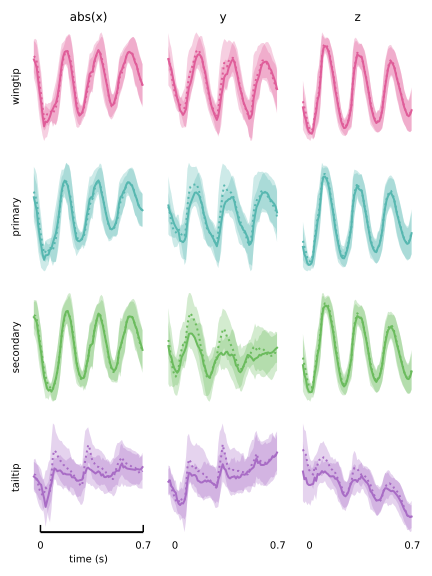

In [3]:
loaded_data = np.load("../data/processed/Toothless_flapping_binned.npz")
markers, times = loaded_data["markers"], loaded_data["times"]
n_markers = 8
print(f"Loaded: {markers.shape[0]} frames, {n_markers} markers")

display(SVG("figures/01_raw_data_overview.svg"))

## 2 — Convergence analysis

Before choosing the number of DMD modes, we run a convergence test: fit DMD with 2, 4, 6, … up to 12 modes and track reconstruction RMSE. The plot below shows that 6 modes (3 conjugate pairs) capture the bulk of the variance; additional modes provide diminishing returns and risk over-fitting noise.

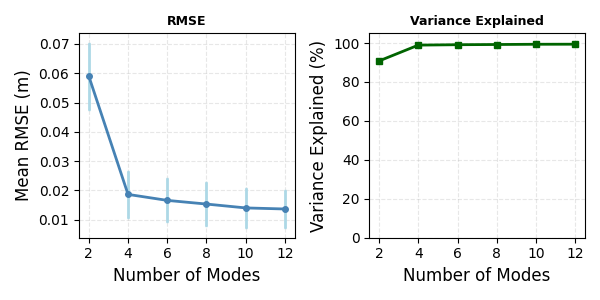

   n_modes  rmse_mean  rmse_std  variance_explained
0        2   0.058970  0.011461            0.908324
1        4   0.018656  0.008137            0.989477
2        6   0.016613  0.007527            0.991549
3        8   0.015359  0.007475            0.992588
4       10   0.014043  0.006793            0.993818
5       12   0.013679  0.006633            0.994129


In [4]:
hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers

conv_results = convergence_analysis(
    markers=markers,
    times=times,
    average_shape=average_shape,
    n_markers=n_markers,
    max_modes=12,
    verbose=False,
)

fig = plot_convergence(conv_results)
fig.savefig("figures/01_convergence.svg", format="svg")
plt.show()

# Print summary
df_summary = pd.DataFrame(
    {
        "n_modes": conv_results["n_modes"],
        "rmse_mean": conv_results["rmse_mean"],
        "rmse_std": conv_results["rmse_std"],
        "variance_explained": conv_results["variance_explained"],
    }
)
print(df_summary)

## 3 — Run DMD with 6 modes (3 conjugate pairs)

We fit DMD with 6 modes, which form three conjugate pairs:

1. **Wingbeat** (~4.5 Hz) — the fundamental flapping frequency, describing the primary vertical stroke of the wings.
2. **Doubled-frequency** (~8.8 Hz) — oscillating at twice the wingbeat rate, this mode captures the asymmetry between upstroke and downstroke (explored further in `03_double_frequency`).
3. **Base** (0 Hz) — a static offset representing the mean wing posture around which the oscillatory modes fluctuate.

In [5]:
N_MODES = 6
D = 2
NEAR_ZERO_HZ = 0.1

result = run_dmd(
    data=markers,
    times=times,
    n_modes=N_MODES,
    d=D,
    eig_constraints={"conjugate_pairs"},
    n_markers=n_markers,
    average_shape=average_shape,
    verbose=True,
)

conjugate_pairs = result.conjugate_pairs
freqs_hz = np.imag(result.eigenvalues) / (2 * np.pi)

print("\nConjugate pairs:")
for idx, (i, j) in enumerate(conjugate_pairs):
    print(f"  Pair {idx + 1}: ({i},{j}), freq = {np.abs(freqs_hz[i]):.2f} Hz")

# Identify 0 Hz (base) pair index
base_pair_idx = None
for idx, (i, _j) in enumerate(conjugate_pairs):
    if np.abs(freqs_hz[i]) < NEAR_ZERO_HZ:
        base_pair_idx = idx
        break

# RMSE order: base first, then the rest
rmse_pair_order = [base_pair_idx] + [
    i for i in range(len(conjugate_pairs)) if i != base_pair_idx
]
print(f"\nBase pair index: {base_pair_idx}")
print(f"RMSE pair order: {rmse_pair_order}")

Running DMD with 6 modes, delay d=2
Input shape: (139, 24)
Number of variables in DMD results: 48
Complex Eigenvalues (log): [-0.813+28.32j  -0.813-28.32j  -0.228+55.056j -0.228-55.056j
 -0.887 -0.j    -0.887 +0.j   ]
Number of modes in Psi: 6

Conjugate pairs:
  Pair 1: (0,1), freq = 4.51 Hz
  Pair 2: (2,3), freq = 8.76 Hz
  Pair 3: (4,5), freq = 0.00 Hz

Base pair index: 2
RMSE pair order: [2, 0, 1]


Fitting DMD with max_modes=10, d=2...
DMD fit complete.


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:973: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


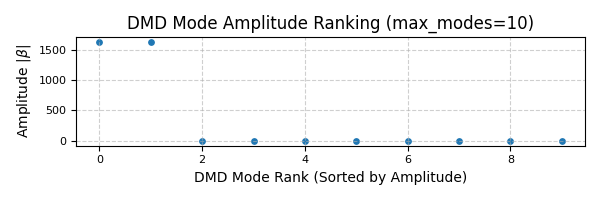

In [6]:
# Amplitude ranking
fig, ax, _ = plot_amplitude_ranking(
    markers,
    times,
    max_modes=10,
    d=D,
    eig_constraints={"conjugate_pairs"},
    normalise_fn=lambda m: normalise_data(m, average_shape),
)
fig.savefig("figures/01_amplitude_ranking.svg", format="svg")
plt.show()

Pair 1 (0,1) Frequency: 4.51 Hz | f=4.51 Hz | λ=-0.813+28.320j
Pair 2 (2,3) Frequency: 8.76 Hz | f=8.76 Hz | λ=-0.228+55.056j
Pair 3 (4,5) Frequency: -0.00 Hz | f=-0.00 Hz | λ=-0.887-0.000j


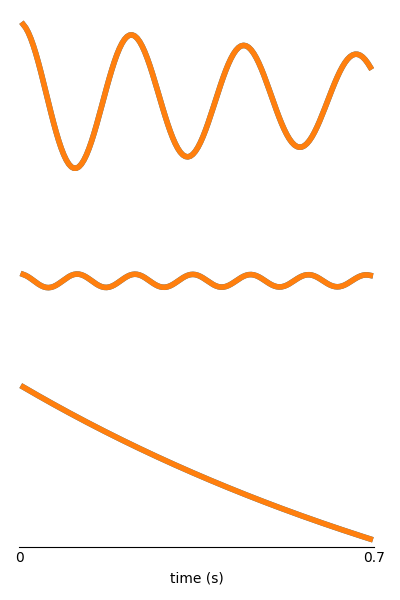

In [7]:
# Mode dynamics
fig = plot_mode_dynamics(
    times[1:],
    result,
    axes_visible=False,
    x_lim=(0, 0.7),
    y_lim=[0.6, 0.6, None],
)
fig.savefig("figures/01_mode_dynamics.svg", format="svg")

> Note the amplitudes are a known bug for now. 

## 4 — Individual mode reconstructions

To understand what each conjugate pair contributes, we reconstruct the 3D marker trajectories from each pair in isolation. The wingbeat pair produces the dominant up–down stroke, the doubled-frequency pair adds asymmetric shaping to the stroke cycle, and the base pair sets the static wing posture. The 3D traces below show each mode's contribution to the eight bilateral markers.

In [8]:
# Reconstruct each conjugate pair separately
pair_labels = ["Wingbeat", "Folding", "Base"]
pair_colours = ["#DF5D99", "#57B7B0", "#EE7447"]

mode_keypoints = []
for pair_idx in range(len(conjugate_pairs)):
    kp = reconstruct(result, times=times[1:], pairs=[pair_idx])
    mode_keypoints.append(kp)
    i, j = conjugate_pairs[pair_idx]
    print(f"Pair {pair_idx + 1} ({pair_labels[pair_idx]}): modes ({i},{j})")

Pair 1 (Wingbeat): modes (0,1)
Pair 2 (Folding): modes (2,3)
Pair 3 (Base): modes (4,5)


In [9]:
# 3D visualisation of individual modes
# for kp, colour in zip(mode_keypoints, pair_colours, strict=True):
#     hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
#     hawk3d.update_keypoints(
#         kp[0]
#     )  # Update to the first frame of the first mode for a better initial view

#     fig = plot_plotly_with_trace(hawk3d, keypoints_frames=kp, colour=colour)
#     fig.update_layout(
#         scene={
#             "camera": {"eye": {"x": 0.0, "y": 1, "z": 0.3}},
#             "xaxis": {"visible": False, "range": [-0.8, 0.8]},
#             "yaxis": {"visible": False, "range": [-0.8, 0.8]},
#             "zaxis": {"visible": False, "range": [-0.8, 0.8]},
#         },
#     )
#     fig.show()

In [10]:
# hawk3d = Hawk3D("../data/mean_hawk_shape.csv")

# animate_plotly_compare(
#     hawk3d, keypoints_frames_list=mode_keypoints, colours=pair_colours
# )

In [11]:
# Save each as a gif
# for pair_idx, (kp, label, colour) in enumerate(
#     zip(mode_keypoints, pair_labels, pair_colours)
# ):
#     ani = animate(hawk3d, kp, colour=colour, az=50, el=30)
#     ani.save(
#         f"figures/01_flapping_modes_{pair_idx}.gif",
#         writer="Pillow", fps=40, dpi=300,
#     )
#     print("Saved GIF")

<img src="figures/01_flapping_modes_0.gif" width="300"/>
<img src="figures/01_flapping_modes_1.gif" width="300"/>
<img src="figures/01_flapping_modes_2.gif" width="300"/>


## 5 — Full reconstruction and RMSE

Summing all three mode pairs recovers the original wingbeat with high fidelity. The mean RMSE is within 1.3% of the wingspan (~1.1 m), confirming that three conjugate pairs are sufficient to describe steady-state flapping in Toothless. See further notebooks for more detail on the reconstruction error. 

In [12]:
# Interactive Comparison

# hawk3d = Hawk3D("../data/mean_hawk_shape.csv")

# animate_plotly_compare(
#     hawk3d,
#     keypoints_frames_list=[result.reconstruction, markers[:-1]],
#     colours=["red", "black"],
# )

In [13]:
# Comparison: all 3 modes vs original
# hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
#
# ani = animate_compare(
#     hawk3d,
#     [result.reconstruction, markers[:-1]],
#     colour=["red", "black"], az=50, el=30,
# )
# ani.save(
#     "figures/01_full_reconstruction_compare.gif",
#     writer="Pillow", fps=40, dpi=300,
# )

<img src="figures/01_full_reconstruction_compare.gif" width="400"/>
